![Facial Recognition](facialrecognition.jpg)

# Facial Recognition - Arnold Schwarzenegger Detection

Un proyecto de Machine Learning para identificar a Arnold Schwarzenegger en imágenes faciales usando el dataset Labeled Faces in the Wild (LFW).

**Dataset:** 40 imágenes de Arnold Schwarzenegger + 150 de otras personas

## 1. Preparación de Datos

In [2]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import numpy as np
from scipy import stats

# Cargar datos
df = pd.read_csv("data/lfw_arnie_nonarnie.csv")
X = df.drop('Label', axis=1)
y = df['Label']

print(f"Dataset: {len(df)} muestras")
print(f"Features: {len(X.columns)}")
print(f"Se usará el 100% de los datos ({len(df)} muestras) con StratifiedKFold para validación.")

Dataset: 190 muestras
Features: 150
Se usará el 100% de los datos (190 muestras) con StratifiedKFold para validación.


### Estadísticas y Distribución del Dataset

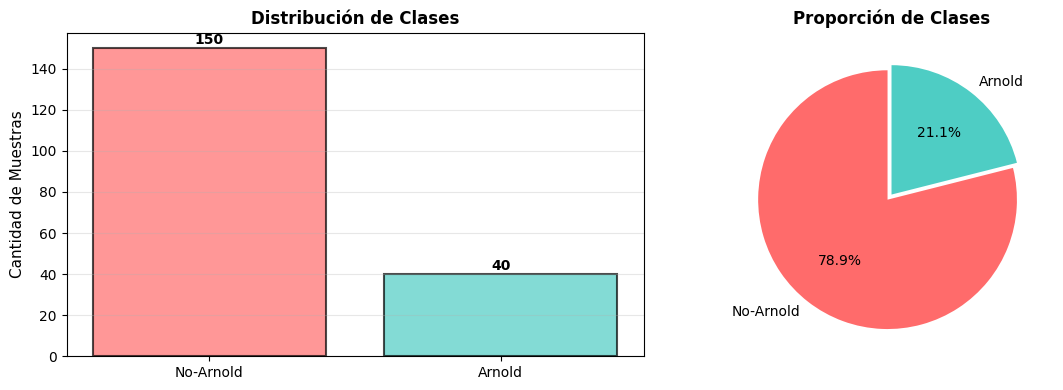

In [3]:
# Visualizar distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
label_counts = df['Label'].value_counts()
labels = ['No-Arnold', 'Arnold']
colors_bar = ['#FF6B6B', '#4ECDC4']
axes[0].bar(labels, label_counts.values, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Cantidad de Muestras', fontsize=11)
axes[0].set_title('Distribución de Clases', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Gráfico de pie
axes[1].pie(label_counts.values, labels=labels, autopct='%1.1f%%', 
           colors=colors_bar, startangle=90, explode=(0.05, 0))
axes[1].set_title('Proporción de Clases', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Definir Hiperparámetros

In [ ]:
params = {
    "logistic_regression": {
        "logistic_regression__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "logistic_regression__max_iter": [100, 500, 1000],
        "logistic_regression__solver": ['lbfgs', 'liblinear']
    },
    "svc": {
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__kernel": ['linear', 'rbf', 'poly'],
        "svc__gamma": ['scale', 'auto', 0.001, 0.01, 0.1],
        "svc__degree": [2, 3, 4]
    },
    "linear_svc": {
        "linear_svc__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "linear_svc__max_iter": [1000, 2000, 5000]
    }
}



## 3. Crear Pipelines y Cross-Validation

In [5]:
pipelines = {
    "logistic_regression": Pipeline([
        ('scaler', StandardScaler()),
        ('logistic_regression', LogisticRegression())
    ]),
    "svc": Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC())
    ]),
    "linear_svc": Pipeline([
        ('scaler', StandardScaler()),
        ('linear_svc', LinearSVC(class_weight='balanced', max_iter=2000))
    ])
}

skf = StratifiedKFold(n_splits=10, random_state=21, shuffle=True)

## 4. Buscar Mejores Hiperparámetros (GridSearchCV)

In [6]:
results = {}

for model_name in pipelines.keys():
    print(f"\nEntrenando {model_name}...")
    
    grid_search = GridSearchCV(
        estimator=pipelines[model_name],
        param_grid=params[model_name],
        cv=skf,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X, y)
    
    results[model_name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'best_estimator': grid_search.best_estimator_,
    }
    
    print(f"CV Score: {grid_search.best_score_:.4f}")



Entrenando logistic_regression...
Fitting 10 folds for each of 36 candidates, totalling 360 fits
CV Score: 0.8368

Entrenando svc...
Fitting 10 folds for each of 225 candidates, totalling 2250 fits
CV Score: 0.8211

Entrenando linear_svc...
Fitting 10 folds for each of 18 candidates, totalling 180 fits
CV Score: 0.7263


## 5. Seleccionar el mejor modelo

In [7]:
# Sacar el modelo con mejor score
best_model_name = max(results.keys(), key=lambda x: results[x]['best_score'])
best_model_cv_score = results[best_model_name]['best_score']
best_model_info = results[best_model_name]['best_params']

# Reentrenar el mejor modelo con el 100% de los datos
best_model = results[best_model_name]['best_estimator']
best_model.fit(X, y)

print(f"\n{'='*60}")
print(f"MEJOR MODELO: {best_model_name}")
print(f"{'='*60}")
print(f"CV Score (validación): {best_model_cv_score:.4f}")
print(f"Modelo reentrenado con el 100% de los datos ({len(X)} muestras).")
print(f"Listo para producción.")



MEJOR MODELO: logistic_regression
CV Score (validación): 0.8368
Modelo reentrenado con el 100% de los datos (190 muestras).
Listo para producción.


### ⚠️ Análisis de Métricas: CV Score y desbalanceo

El CV Score del mejor modelo es **0.8368**, pero hay que interpretarlo con cautela: 
el dataset está **desbalanceado** (150 no-Arnold vs 40 Arnold), por lo que un modelo que prediga casi siempre "No-Arnold" puede obtener una accuracy alta de forma engañosa.

## 6. Visualizar Resultados

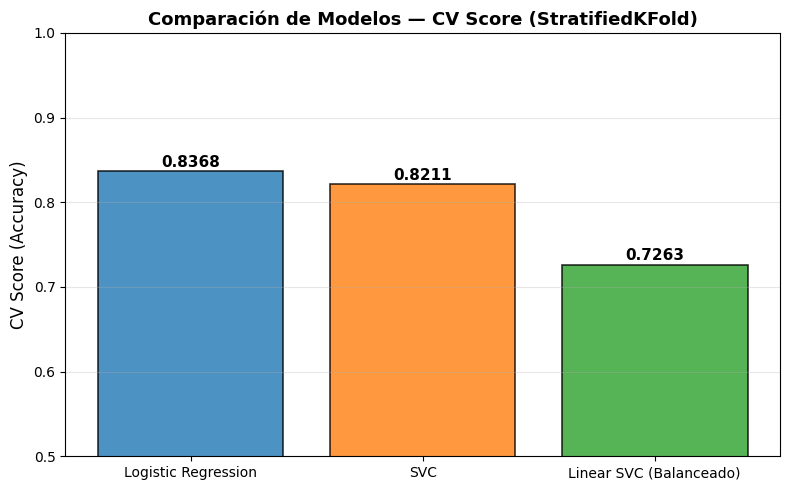

In [8]:
# Comparación de CV Scores por modelo
model_names_display = {
    'logistic_regression': 'Logistic Regression',
    'svc': 'SVC',
    'linear_svc': 'Linear SVC (Balanceado)'
}

fig, ax = plt.subplots(figsize=(8, 5))
names = [model_names_display[m] for m in results.keys()]
scores = [results[m]['best_score'] for m in results.keys()]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

bars = ax.bar(names, scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('CV Score (Accuracy)', fontsize=12)
ax.set_title('Comparación de Modelos — CV Score (StratifiedKFold)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.4f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


In [9]:
# Tabla resumen de CV Scores de todos los modelos
import pandas as pd

summary_data = []
for model_name, info in results.items():
    summary_data.append({
        'Modelo': model_names_display.get(model_name, model_name),
        'CV Score': f"{info['best_score']:.4f}",
        'Mejor Parámetros': str(info['best_params'])
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


                 Modelo CV Score                                                                                                   Mejor Parámetros
    Logistic Regression   0.8368 {'logistic_regression__C': 0.01, 'logistic_regression__max_iter': 100, 'logistic_regression__solver': 'liblinear'}
                    SVC   0.8211                                 {'svc__C': 0.01, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Linear SVC (Balanceado)   0.7263                                                               {'linear_svc__C': 100, 'linear_svc__max_iter': 1000}


## 7. Exportar Modelo

In [10]:
all_models_filename = 'all_models.pkl'
joblib.dump(results, all_models_filename)
print(f"✓ Todos los modelos guardados: {all_models_filename}")

✓ Todos los modelos guardados: all_models.pkl


In [11]:
model_filename = f'best_model_{best_model_name}.pkl'
joblib.dump(best_model, model_filename)
print(f"✓ Modelo exportado: {model_filename}")

metadata = {
    'best_model': best_model_name,
    'best_cv_score': float(best_model_cv_score),
    'best_params': best_model_info,
    'dataset_info': {
        'total_samples': len(df),
        'features': len(X.columns),
        'trained_on': '100% of dataset (production model)'
    }
}

metadata_filename = f'model_metadata_{best_model_name}.pkl'
joblib.dump(metadata, metadata_filename)
print(f"✓ Metadatos guardados: {metadata_filename}")


✓ Modelo exportado: best_model_logistic_regression.pkl
✓ Metadatos guardados: model_metadata_logistic_regression.pkl


## Conclusión

Se entrenaron y compararon tres modelos de clasificación usando **StratifiedKFold (10 folds)** sobre el 100% de los datos, 
eliminando la necesidad de reservar un 20% para test.

El mejor modelo (**Logistic Regression**) obtuvo un CV Score de **0.8368**. 
Una vez seleccionado, fue **reentrenado con la totalidad del dataset (190 muestras)** para maximizar su conocimiento antes de exportarlo a producción.

El desbalanceo del dataset (40 Arnold vs 150 no-Arnold) limita el rendimiento en la clase minoritaria, 
lo que abre la puerta a futuras mejoras mediante técnicas de balanceo de clases.

## 8. Usar el Modelo Exportado

In [12]:
# Cargar el mejor modelo entrenado
loaded_model = joblib.load(model_filename)
print(f"✓ Modelo cargado: {model_filename}")

✓ Modelo cargado: best_model_logistic_regression.pkl


In [13]:
# Ver lo que realmente se ha serializado
print(loaded_model.steps)

[('scaler', StandardScaler()), ('logistic_regression', LogisticRegression(C=0.01, solver='liblinear'))]


In [14]:
# Cargar metadatos
loaded_metadata = joblib.load(metadata_filename)

print(f"Mejor Modelo: {loaded_metadata['best_model']}")
print(f"CV Score: {loaded_metadata['best_cv_score']:.4f}")
print(f"\nInfo del dataset:")
for key, value in loaded_metadata['dataset_info'].items():
    print(f"  {key}: {value}")


Mejor Modelo: logistic_regression
CV Score: 0.8368

Info del dataset:
  total_samples: 190
  features: 150
  trained_on: 100% of dataset (production model)


In [15]:
# Hacer predicciones con el modelo cargado
predictions_loaded = loaded_model.predict(X)
accuracy_loaded = accuracy_score(y, predictions_loaded)

print(f"Precisión del modelo cargado en test set: {accuracy_loaded:.4f}")
print(f"Predicciones (primeras 10): {predictions_loaded[:10]}")
print(f"Valores reales (primeras 10):  {y.values[:10]}")

Precisión del modelo cargado en test set: 1.0000
Predicciones (primeras 10): [1 1 1 1 1 1 1 1 1 1]
Valores reales (primeras 10):  [1 1 1 1 1 1 1 1 1 1]


In [16]:
# Comparar rendimiento de todos los modelos exportados
all_models = joblib.load(all_models_filename)

print(f"\n{'='*60}")
print("COMPARACIÓN DE TODOS LOS MODELOS ENTRENADOS")
print(f"{'='*60}")

comparison_data = []
for model_name, model_info in all_models.items():
    comparison_data.append({
        'Modelo': model_name,
        'CV Score': f"{model_info['best_score']:.4f}",
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print(f"{'='*60}")



COMPARACIÓN DE TODOS LOS MODELOS ENTRENADOS
             Modelo CV Score
logistic_regression   0.8368
                svc   0.8211
         linear_svc   0.7263


In [17]:
# Hacer predicción en datos nuevos
import numpy as np

# Simular nuevos datos de entrada (misma dimensión que X)
new_sample = X.iloc[0:5]

# Predicción
predictions_new = loaded_model.predict(new_sample)

print(f"\nPredicciones en nuevas muestras:")
for i, pred in enumerate(predictions_new):
    label = "Arnold" if pred == 1 else "No-Arnold"
    print(f"  Muestra {i+1}: {label}")


Predicciones en nuevas muestras:
  Muestra 1: Arnold
  Muestra 2: Arnold
  Muestra 3: Arnold
  Muestra 4: Arnold
  Muestra 5: Arnold
